In [29]:
from typing import List,TypedDict,Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [30]:
docs = (
    PyPDFLoader("documents/Company_Policies.pdf").load()
    + PyPDFLoader("documents/Company_Profile.pdf").load()
    + PyPDFLoader("documents/Product_and_Pricing.pdf").load()
)

In [31]:
chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)

In [32]:
len(chunks)

16

In [33]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vector_stores = FAISS.from_documents(chunks,embeddings)

In [34]:
retriever = vector_stores.as_retriever(search_type="similarity",search_kwargs={"k":1})

In [35]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

## Graph State

In [36]:
class State(TypedDict):

    question: str
    need_retrieval : bool

    docs : List[Document]

    answer : str

### Retrieve Decision Node

In [37]:
class RetrieveDecision(BaseModel):
    should_retrieve : bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human","Question: {question}")
    ]
)

decide_retrieval_chain = decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):
    out = decide_retrieval_chain.invoke({"question": state['question']})

    return {"need_retrieval": out.should_retrieve}

### Generation Node

In [38]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your knowledge"
        ),
        ("human","{question}")
    ]
)

def generate_direct(state: State):

    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state['question']
        )
    )

    return {"answer": out.content}

## Retrieve Node

In [39]:
def retrieve(state: State):

    return {"docs": retriever.invoke(state['question'])}

### Router Node

In [40]:
def route_after_decide(state : State):

    if state['need_retrieval']:
        return "retrieve"
    return "generate_direct"

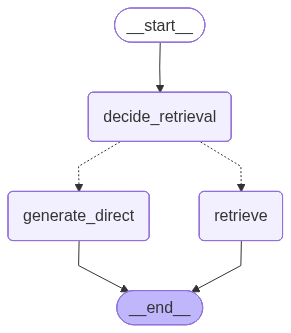

In [41]:
g = StateGraph(State)

g.add_node("decide_retrieval",decide_retrieval)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)

g.add_edge(START,"decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve"
    },
)

g.add_edge("generate_direct",END)
g.add_edge("retrieve",END)

app = g.compile()
app


In [42]:
result = app.invoke({"question":"who is the CEO of nexa AI"})

In [43]:
result['need_retrieval']

True

In [44]:
result['docs']

[Document(id='6b83a979-b0a3-4847-ab6d-c90af313e4a0', metadata={'producer': 'ReportLab PDF Library - www.reportlab.com', 'creator': '(unspecified)', 'creationdate': '2026-02-14T13:07:17+00:00', 'author': '(anonymous)', 'keywords': '', 'moddate': '2026-02-14T13:07:17+00:00', 'subject': '(unspecified)', 'title': '(anonymous)', 'trapped': '/False', 'source': 'documents/Company_Profile.pdf', 'total_pages': 2, 'page': 1, 'page_label': '2'}, page_content='Founder\nAarav Mehta founded NexaAI after over 10 years of experience in enterprise data platforms and\ncloud infrastructure.\nHe previously worked with global consulting firms where he led multiple large-scale digital\ntransformation projects.\nLeadership Team\nThe leadership team brings experience across AI engineering, product management, and business\noperations.\n\x7f\nAarav Mehta – CEO & Founder\n\x7f\nRiya Kapoor – CTO (Distributed systems & AI platforms)\n\x7f\nKunal Sharma – Head of Product\n\x7f\nNeha Verma – Head of Operations & H

In [45]:
result1 = app.invoke({"question":"what is operating System"})

In [49]:
result1['need_retrieval']

False

In [48]:
result1['answer']

"An **operating system (OS)** is the most important software that runs on a computer. It acts as an intermediary between the computer's hardware and the user or applications.\n\nThink of it as the **manager** of your computer. Its main responsibilities include:\n\n*   **Managing Hardware Resources:** The OS controls and allocates the computer's resources like the CPU (processor), memory (RAM), storage devices (hard drives, SSDs), and input/output devices (keyboard, mouse, printer). It ensures that different programs can share these resources efficiently and without conflict.\n\n*   **Providing a User Interface:** The OS presents a way for you to interact with the computer. This can be a graphical user interface (GUI) with icons, windows, and menus (like Windows, macOS), or a command-line interface (CLI) where you type commands (like some versions of Linux).\n\n*   **Managing Files and Directories:** The OS organizes and manages all the files and folders on your storage devices, allowin